# Towards Reliable AI Agents

## 1. Introduction

A capable agent can still be an unsafe system.

In July 2025, a Replit coding agent deleted a live production database during a code freeze, despite instructions forbidding changes. In February 2024, a Canadian tribunal ordered Air Canada to pay damages after its chatbot invented a bereavement-refund policy; the airline argued the chatbot was a separate entity, and the tribunal rejected that defense. OpenAI's Operator bought eggs for $31.43 without asking for confirmation. New York City's business chatbot gave ten journalists ten different wrong answers.

These incidents expose the same evaluation gap. Benchmarks ask whether an agent can complete a task once. Deployment asks whether the agent behaves correctly, consistently, robustly, predictably, and safely across repeated real interactions.

Agents are not pure functions. They are stochastic systems assembled from a model, prompt, memory, tools, policies, permissions, orchestration, and external state. A single green run tells us little about their behavior distribution.

Two publications set the direction for building reliable enterprise agent systems through systematic measurement and improvement:

- **τ-bench** proved agent success rates hide inconsistency — and gave us pass^k to measure it. https://arxiv.org/pdf/2406.12045
- **Towards a Science of AI Agent Reliability** proved reliability lags capability — 0.03/yr vs 0.21/yr — and gave us four dimensions to measure it: consistency, robustness, predictability, safety. https://arxiv.org/pdf/2602.16666


## 2. **τ-bench**: task success is not enough

A deployed enterprise agent faces conditions that classic one-shot benchmarks rarely model:

- users reveal intent incrementally and imprecisely;
- tools expose partial and changing state;
- policy documents constrain permitted actions;
- some actions modify persistent records;
- millions of similar requests must receive similar treatment.

Benchmarks are the feedback loop of agent engineering. Without a reproducible evaluation environment, failures remain anecdotes, prompt changes are hard to compare, model upgrades introduce silent regressions, and teams optimize whatever aggregate score is easiest to observe.

The missing question is not `Can it succeed?` but `Will it behave reliably in production?`


In [1]:
# Example 1: one successful run doesn't mean agent is reliable

import random

def deterministic_fn(x):
    """A function: same input -> same output, forever."""
    return x * 2

def stochastic_agent(rng, p_success=0.90):
    """An agent: a distribution over behaviors. Succeeds with prob p_success."""
    return "correct" if rng.random() < p_success else "wrong"

rng = random.Random(0)

# The deterministic-software habit: run it once, it's green, ship it.
print("Single run:", stochastic_agent(rng))          # looks fine

# The reality the single run hides:
N = 10_000
successes = sum(stochastic_agent(rng) == "correct" for _ in range(N))
print(f"Over {N:,} runs: {successes / N:.1%} succeed")
print("One passing run says almost nothing about the distribution behind it.")

Single run: correct
Over 10,000 runs: 90.4% succeed
One passing run says almost nothing about the distribution behind it.


### 2.1. Environment design

τ-bench models customer-service agents in two domains:

- **τ-retail:** 115 tasks, 500 users, 50 products, 1,000 orders, and 15 API tools.
- **τ-airline:** 50 tasks, 500 users, 300 flights, 2,000 reservations, and 13 tools. Airline tasks are harder because rules depend on fare class, cabin, membership, timing, and payment method.

Sierra later extended the benchmark. τ²-bench added a telecom domain and dual-control tasks, where user and agent both call tools. τ³-bench added a banking domain, a voice modality, and corrections to the original airline and retail tasks.

Each environment contains a database, API tools, a natural-language policy, simulated users, and tasks with annotated goal states.
The agent cannot see the user's hidden goal or the database directly; it must infer intent through dialogue and inspect or modify state through tools. This matters because production agent work is partially observable. The task is not merely selecting the right function. The agent must ask for missing information, retrieve state, apply business rules, call tools with correct arguments, and communicate the result.

**Simulated user.** An LLM plays the customer. The simulated user receives a hidden instruction fixing identity, intent, and preferences.  ("You are Mia Li. You want to fly to SF instead of LA. You are concise."). Sampling creates varied conversations for the same underlying task, to model natural variation. That makes repeated trials cheap, which is the raw material for reliability measurement.

**Outcome-based evaluation.** The heart of the design: A task is successful only when the final database state matches the annotated goal and the required information appears in the agent's messages:

$$
r = r_{\text{action}} \times r_{\text{output}} \in \{0,1\}
$$

Grading compares end states, not paths, so it is trajectory-invariant: any tool-call sequence that reaches the goal state scores 1 — no reference trajectory to match and no LLM judge in the loop ($r_{\text{output}}$ is a substring check on the transcript). Both terms are deterministic and cheap to recompute, which is exactly what makes drawing many samples per task — and reporting `pass^k` over them — affordable.

The cost moves to annotation: each task needs a hand-labeled goal state, and any task with more than one valid ending must enumerate every acceptable end state, or correct runs are scored as failures. τ-bench's authors ran 40+ trials per retail task to flush out these ambiguities before fixing the target.

Because the two terms multiply, a run that gets the database right but forgets to tell the customer scores exactly the same as one that says the right thing over a wrong database — zero. That keeps grading objective and rerunnable, but it checks only the *endpoint*. It cannot see an agent that reaches the correct state while skipping a required step — for example, issuing the refund without the mandated confirmation.


In [2]:
# Example 2: tau-bench's reward is a product -- right state AND right words, or 0.
# The final STATE must match the goal AND the required facts must reach the
# customer. Either one alone scores 0 -- there is no partial credit.

def reward(final_db, goal_db, messages, required_info):
    """tau-bench reward: correct final STATE (r_action) AND correct MESSAGE (r_output)."""
    r_action = int(final_db == goal_db)
    said = " ".join(messages).lower()
    r_output = int(all(info.lower() in said for info in required_info))
    return r_action * r_output, r_action, r_output


goal_db       = {"order": "A100", "status": "refunded", "refund": 120}
required_info = ["refunded $120"]          # every fact here must be stated to the customer

cases = {
    "A  right state, never told the customer": (
        {"order": "A100", "status": "refunded", "refund": 120},
        ["Anything else I can help with?"]),
    "B  told the customer, but DB left wrong": (
        {"order": "A100", "status": "paid", "refund": 0},
        ["Your order A100 has been refunded $120."]),
    "C  both correct": (
        {"order": "A100", "status": "refunded", "refund": 120},
        ["Your order A100 has been refunded $120."]),
}

for name, (final_db, messages) in cases.items():
    r, r_action, r_output = reward(final_db, goal_db, messages, required_info)
    print(f"{name:42s}  r_action={r_action}  r_output={r_output}  ->  r={r}")

print("\nThe product is unforgiving: right state OR right words alone still scores 0.")

A  right state, never told the customer     r_action=1  r_output=0  ->  r=0
B  told the customer, but DB left wrong     r_action=0  r_output=1  ->  r=0
C  both correct                             r_action=1  r_output=1  ->  r=1

The product is unforgiving: right state OR right words alone still scores 0.


Because the two terms multiply, a run that gets the database right but forgets to tell the customer scores exactly the same as one that says the right thing over a wrong database — zero. That keeps grading objective and rerunnable, but it checks only the *endpoint*. It cannot see an agent that reaches the correct state while skipping a required step — for example, issuing the refund without the mandated confirmation. Catching that needs explicit procedural and safety checks, which the reliability study scores as a separate dimension (Section 6).

### 2.2. `pass@k` and `pass^k`

The paper introduces `pass^k` as a complement to the commonly used `pass@k` metric. The two metrics answer different questions.

`pass@k` measures the probability that **at least one** of `k` attempts succeeds. It suits code generation, where a model produces several candidates and a test suite selects a correct one. More attempts improve the odds of finding one.

`pass^k` measures the probability that **all** `k` attempts succeed. It suits customer-facing and business-critical deployment. A customer receives one execution, not a shortlist. Repeating the task must keep producing the correct result.

For a task evaluated `n` times with `c` successful runs, the metrics are estimated as:

$$
\text{pass}^{\wedge}k = \mathbb{E}_{\text{task}}\!\left[\frac{\binom{c}{k}}{\binom{n}{k}}\right] \qquad\qquad \text{pass@}k = 1 - \mathbb{E}_{\text{task}}\!\left[\frac{\binom{n-c}{k}}{\binom{n}{k}}\right]
$$

The difference is important:

* `pass@k` increases as more attempts are allowed, because only one attempt must succeed.
* `pass^k` decreases as more successful repetitions are required, because every attempt must succeed.

For example, suppose an agent has a 90% probability of succeeding on any individual run. Assuming independent runs:

$$
\mathrm{pass}^{8} \approx 0.9^{8} \approx 43\%
$$

The agent looks strong when measured by single-run accuracy, but it has less than a 50% chance of completing the same task correctly eight times in a row.

In [3]:
# Example 3: pass@k rises with retries, but pass^k (all k must pass) collapses -- production wants pass^k.

from math import comb


def pass_at_k(n, c, k):
    if k > n:
        raise ValueError("k cannot exceed n")
    if n - c < k:
        return 1.0
    return 1 - comb(n - c, k) / comb(n, k)


def pass_power_k(n, c, k):
    if k > n:
        raise ValueError("k cannot exceed n")
    if c < k:
        return 0.0
    return comb(c, k) / comb(n, k)


n, c = 40, 36  # 90% observed single-run success
print(" k | pass@k | pass^k | p^k plug-in")
print("---|--------|--------|------------")
for k in [1, 2, 4, 8, 12]:
    p = c / n
    print(f"{k:2d} | {pass_at_k(n, c, k):6.3f} | {pass_power_k(n, c, k):6.3f} | {p ** k:10.3f}")

 k | pass@k | pass^k | p^k plug-in
---|--------|--------|------------
 1 |  0.900 |  0.900 |      0.900
 2 |  0.992 |  0.808 |      0.810
 4 |  1.000 |  0.645 |      0.656
 8 |  1.000 |  0.393 |      0.430
12 |  1.000 |  0.224 |      0.282


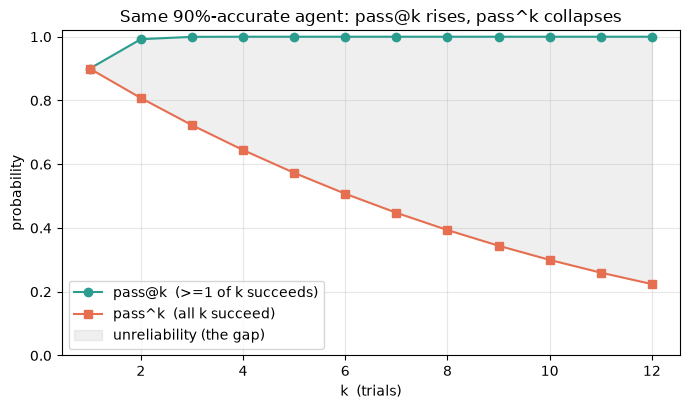

In [4]:
# Example 3, visualized: same 90% agent -- pass@k climbs to 1, pass^k decays; the gap is unreliability.

import matplotlib.pyplot as plt

ks = list(range(1, 13))
pa = [pass_at_k(n, c, k) for k in ks]      # pass@k: >= 1 of k succeeds
ph = [pass_power_k(n, c, k) for k in ks]   # pass^k: all k succeed

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(ks, pa, "o-", color="#2a9d8f", label="pass@k  (>=1 of k succeeds)")
ax.plot(ks, ph, "s-", color="#e76f51", label="pass^k  (all k succeed)")
ax.fill_between(ks, ph, pa, alpha=0.12, color="gray", label="unreliability (the gap)")
ax.set_xlabel("k  (trials)")
ax.set_ylabel("probability")
ax.set_ylim(0, 1.02)
ax.set_title("Same 90%-accurate agent: pass@k rises, pass^k collapses")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

`pass@k` rises as more attempts are allowed. `pass^k` falls as repeated correctness is demanded. The gap between the curves is the difference between search capability and service reliability.

### 2.3 What τ-bench found

In the original 2024 study, the best configuration — GPT-4o with native function calling — reached **61.2%** `pass^1` on retail and **35.2%** on airline (48.2% averaged across the two domains). Retail `pass^8` fell below **25%**: run the same task eight times, and it succeeds every time less than a quarter of the time. A task the agent could solve once, it often could not solve *every* time.

Failure analysis of 36 failed retail runs found three dominant classes — and each points to a different fix:

- **~55% — wrong argument or wrong information.** Weak state tracking → add input validation.
- **~25% — wrong policy decision.** Weak rule-following → add policy boundary tests.
- **~19% — partial completion of a multi-step request.** Weak planning → add completion checks.

A policy ablation was especially useful. Researchers deleted the policy document and re-scored the agent. On retail the score fell 4.4 points. On airline it fell 22.4 points.
Retail tasks are based on common sense, so the rules barely mattered.
Airline needs the fine print — fare class, cabin, timing — so the rules mattered a lot.
Conclusion - always test against the client's real policies.

**Where the numbers stand today.** Those 2024 figures are historical. On τ³-bench, top agents now exceed 98% on telecom, but no model breaks 27% on banking. Capability rose. It did not become uniform, and — as the next section shows — it did not bring reliability with it.


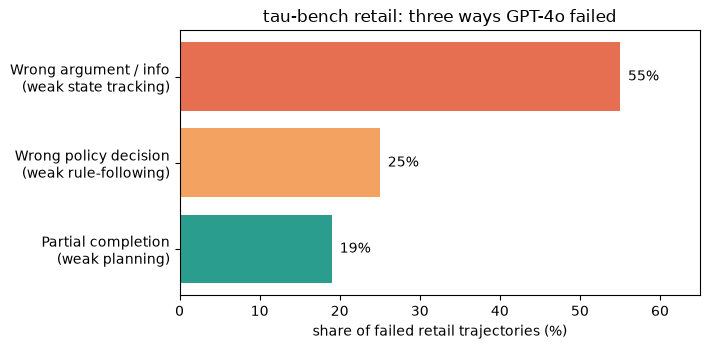

In [5]:
# Example 4: three ways GPT-4o failed on tau-bench retail (36 failed trajectories, 2024).

import matplotlib.pyplot as plt

labels = ["Wrong argument / info\n(weak state tracking)",
          "Wrong policy decision\n(weak rule-following)",
          "Partial completion\n(weak planning)"]
share  = [55, 25, 19]     # % of 36 failed retail trajectories

fig, ax = plt.subplots(figsize=(7.2, 3.6))
bars = ax.barh(labels, share, color=["#e76f51", "#f4a261", "#2a9d8f"])
ax.invert_yaxis()                          # largest class on top
ax.set_xlim(0, 65)
ax.set_xlabel("share of failed retail trajectories (%)")
ax.set_title("tau-bench retail: three ways GPT-4o failed")
for bar, s in zip(bars, share):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{s}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

## 3. Towards a Science of AI Agent Reliability

### 3.1 Capability outran reliability

Rabanser, Kapoor, Kirgis, Liu, Utpala, and Narayanan evaluated 15 agentic models on GAIA (General AI Assistants) and τ-bench, proposing twelve metrics across four dimensions: consistency, robustness, predictability, safety.

Their headline result: over eighteen months of model releases on GAIA, accuracy climbed at **0.21 per year** while aggregate reliability climbed at **0.03 per year** — a factor of seven. Capability gains did not transfer to reliability.

Why accuracy alone cannot reveal this: equal accuracy hides opposite deployment profiles. One agent fails on the same identifiable 10% of tasks every time; those tasks route to humans. Another fails randomly on 10% of every task class. Both score 90%. Only the first supports predictable automation.

The paper:

1) Shows that agent's capability improved faster than reliability.
2) Provides detailed metrics for measuring agents reliability. It breaks-down reliability problem taking concepts from fields that solved this decades ago — aviation, nuclear, automotive, rail: domains where reliability is non-negotiable requirement. The authors evaluate agentic models on GAIA (General AI Assistants) and τ-bench using four dimensions:

   - consistency;
   - robustness;
   - predictability;
   - safety.


### 3.2 Consistency: repeated runs still diverge

Consistency asks whether the same task under the same conditions produces the same result.

The evaluation runs each task e.g. $K=5$ times at temperature zero. However outputs still vary. Other factors such as floating-point non-associativity, batching, and implementation details can alter execution. Temperature zero reduces randomness, but it does not guarantee determinism.

Outcome consistency compares each task’s observed variance with the maximum Bernoulli variance at the same success rate:

$$
C_{\text{out}} = \frac{1}{T}\sum_{t=1}^{T}\left[1 - \frac{\hat{\sigma}^2_t}{\hat{p}_t(1-\hat{p}_t) + \epsilon}\right]
$$

Here, $\hat{p}_t$ is the task success rate across $K$ runs, $\hat{\sigma}^2_t$ is the variance across those $K$ runs, and $\epsilon$ prevents division by zero. The formula divides each task's observed variance by the largest variance possible at that success rate, so it measures agreement rather than difficulty: a task scores near 1 when its $K$ runs reach the same outcome — all succeed or all fail — and falls toward 0 when they split. That is why $C_{\text{out}}$ separates consistency from capability. pass^k cannot, because success is built into its definition: an agent that fails every run scores 0 even though its behavior never varies, which makes consistent failure indistinguishable from erratic failure.

To make the formula concrete, take three tasks, each run $K=5$ times (1 = success, 0 = failure):

| task | $K=5$ runs | $\hat{p}_t$ | $\hat{\sigma}^2_t$ | $\hat{p}_t(1-\hat{p}_t)$ | term $=1-\hat{\sigma}^2_t/[\hat{p}_t(1-\hat{p}_t)+\epsilon]$ |
|------|-----------|-------------|--------------------|--------------------------|-------------------------------------------------------------|
| A | 1, 1, 1, 1, 1 | 1.0 | 0.00 | 0.00 | $\approx 1$ |
| B | 0, 0, 0, 0, 0 | 0.0 | 0.00 | 0.00 | $\approx 1$ |
| C | 1, 1, 1, 0, 0 | 0.6 | 0.24 | 0.24 | $0$ |

Tasks A and B are capability opposites — one always succeeds, one always fails — yet each scores a consistency term of 1, because within a task every run agrees. Task C splits three-to-two and scores 0. Averaging the three gives $C_{\text{out}} = (1+1+0)/3 \approx 0.67$.

This exposes what the metric rewards. For a binary outcome the run variance $\hat{\sigma}^2_t$ equals $\hat{p}_t(1-\hat{p}_t)$ exactly whenever the runs disagree, so the term collapses to 1 for a unanimous task and 0 for any split. $C_{\text{out}}$ is therefore just the fraction of tasks that return the same verdict on all $K$ runs — an agent unanimous on 82 of 100 tasks scores 0.82, whether those verdicts are 82 clean successes or a mix of stable successes and stable failures.

Outcome consistency, though, captures only the endpoint. Two runs can both succeed while reaching that success by materially different paths, and grading on final state alone cannot see the difference. For enterprise agents that difference is consequential, because the order in which actions occur bears on safety, recoverability, and auditability.

The paper therefore evaluates trajectory consistency at two levels. First, it measures whether agents choose similar kinds of actions across runs, using [Jensen–Shannon divergence](https://www.cise.ufl.edu/~anand/sp06/jensen-shannon.pdf). Second, it measures whether agents perform those actions in a similar order, using Levenshtein distance over action sequences.

The results reveal a consistent pattern: agents often choose the same types of actions, but they do not reliably perform them in the same sequence.

That distinction is important in transactional systems. An agent may check inventory before charging in one run and charge first in another. Both paths may succeed under normal conditions, but an interruption can leave different system states. One path is recoverable; the other may create an incorrect charge, inconsistent records, or a harder audit trail.

The paper also finds that smaller models are often more consistent than larger models in the same family. Larger models can identify more valid ways to complete a task, but this wider solution space increases run-to-run variation. Capability may improve while process consistency stays flat or declines.

The practical implication is that evaluating only final success can hide operational risk. Reliable agents must produce not only correct outcomes, but also sufficiently stable execution paths.

In [6]:
# Example 5: consistency is not capability.
# C_out scores how often an agent's K repeated runs of a task AGREE -- not whether they
# succeed. Below we hardcode three agents (so you can read the exact source data), then
# run the same metric on each. Two of them share 90% accuracy yet score far apart.

from statistics import pvariance

EPS = 1e-9   # guard for 0/0 when a task is unanimous (its max variance is 0)


# ===================== the metric =====================
def task_consistency(runs):
    """Consistency of ONE task from its K runs (1 = success, 0 = failure).
    1.0 when all runs agree; ~0.0 when they split. (For binary runs the variance
    equals p*(1-p) the moment the runs disagree, so the term is either 1 or 0.)"""
    p            = sum(runs) / len(runs)   # p_hat: this task's success rate
    variance     = pvariance(runs)         # how much the K runs actually spread
    max_variance = p * (1 - p)             # the most spread possible at this p
    return 1 - variance / (max_variance + EPS)


def c_out(tasks):
    """C_out: the mean task_consistency across all of an agent's tasks."""
    return sum(task_consistency(runs) for runs in tasks) / len(tasks)


# ===================== source data (hardcoded) =====================
# Three agents, 10 tasks each, K = 5 runs per task. Trace any row to the table below.
PASS        = [1, 1, 1, 1, 1]   # succeeds on every run
FAIL        = [0, 0, 0, 0, 0]   # fails on every run
MOSTLY_PASS = [1, 1, 1, 1, 0]   # 4/5 -- inconsistent, not reproduced every time
SPLIT       = [1, 1, 1, 0, 0]   # 3/5 -- inconsistent

# systematic: the SAME one task always fails; the failure never moves.
systematic  = [PASS, PASS, PASS, PASS, PASS, PASS, PASS, PASS, PASS, FAIL]

# random: same 90% accuracy, but the failures are SCATTERED across tasks
# (on a rerun they would land on yet other tasks) -- few tasks come out identical.
scattered   = [PASS, PASS, PASS, PASS, PASS, PASS, MOSTLY_PASS, MOSTLY_PASS, MOSTLY_PASS, SPLIT]

# always-fails: 0% accuracy, yet perfectly stable -- every run of every task fails.
always_fail = [FAIL, FAIL, FAIL, FAIL, FAIL, FAIL, FAIL, FAIL, FAIL, FAIL]


# ===================== report (auxiliary) =====================
def accuracy(tasks):
    """Fraction of all runs that succeeded -- capability, shown only for contrast."""
    return sum(sum(runs) for runs in tasks) / sum(len(runs) for runs in tasks)


print(f"{'agent':30s}  accuracy   C_out")
print("-" * 47)
for name, tasks in [("systematic (stable 10% fail)", systematic),
                    ("random (failures scatter)",    scattered),
                    ("always-fails",                 always_fail)]:
    print(f"{name:30s}    {accuracy(tasks):4.0%}     {c_out(tasks):.2f}")

print("\nSame 90% accuracy, opposite consistency -- and C_out = 1.00 at 0% accuracy shows")
print("consistency is not capability: a perfectly stable agent can be perfectly wrong.")

agent                           accuracy   C_out
-----------------------------------------------
systematic (stable 10% fail)       90%     1.00
random (failures scatter)          90%     0.60
always-fails                        0%     1.00

Same 90% accuracy, opposite consistency -- and C_out = 1.00 at 0% accuracy shows
consistency is not capability: a perfectly stable agent can be perfectly wrong.


Both agents are near 90% accurate. The systematic agent supports selective automation because the failure region is stable. The random agent does not: any task can fail on a later run.

### 3.3 Robustness: what happens when variables change

Robustness measures whether performance survives changed conditions. The paper compares perturbed accuracy with baseline accuracy:

$$
R = \min\left(\frac{\text{Acc}_{\text{perturbed}}}{\text{Acc}_{\text{baseline}}},\; 1\right)
$$

Both terms are ordinary accuracies — the fraction of tasks the agent solves, i.e. its $\text{pass}^1$ rate. $\text{Acc}_{\text{baseline}}$ is measured on the original tasks; $\text{Acc}_{\text{perturbed}}$ is the fraction of those *same* tasks the agent still solves once the perturbation is applied.

$R$ is the ratio of the two, capped at 1, so it ranges over $[0, 1]$: $R = 1$ means accuracy fully survived the perturbation, $R = 0.5$ that half of it is gone, $R = 0$ that it collapsed. The cap matters because robustness measures performance *retained*, not gained — a perturbation that happens to raise accuracy still scores 1, never more.

The paper applies three kinds of perturbation:

- API timeouts and HTTP 503s, injected with $p_{\text{fault}}=0.2$;
- environment changes, such as reordered JSON fields or renamed parameters;
- five semantically equivalent prompt rewrites per task.

These are illustrative of what can shift in production, not an exhaustive list — a deployed agent meets many more.

To make the computation concrete, take 10 tasks. The agent solves 9 of them under the original wording, so $\text{Acc}_{\text{baseline}} = 9/10 = 0.90$. Now apply each perturbation to those same 10 tasks and count how many the agent still solves; that count over 10 is $\text{Acc}_{\text{perturbed}}$:

| condition | tasks solved | $\text{Acc}_{\text{perturbed}}$ | $R = \min(\text{Acc}_{\text{perturbed}}/0.90,\ 1)$ |
|---|---|---|---|
| baseline (original wording) | 9/10 | 0.90 | — |
| API faults (503s) | 8/10 | 0.80 | 0.89 |
| environment change (JSON reorder) | 10/10 | 1.00 | 1.00 |
| prompt paraphrase (×5 rewrites) | 5/10 | 0.50 | 0.56 |

Read each row against the baseline. The faults cost one task — the agent solves 8 of 10, so $\text{Acc}_{\text{perturbed}} = 0.80$ and $R = 0.80/0.90 = 0.89$: almost all performance survives. The environment change is the edge case: it happens to solve one *more* task (10 of 10), which would make the raw ratio $1.00/0.90 = 1.11$, but the cap holds $R$ at 1.00 — robustness never credits a lucky gain. Paraphrasing is the breaker: only 5 of 10 tasks survive the reworded requests, so $\text{Acc}_{\text{perturbed}} = 0.50$ and $R = 0.50/0.90 = 0.56$ — nearly half the performance is gone.

The pattern generalizes across models: faults and environment changes barely move $R$, while prompt paraphrases drive the largest drops. An agent can recover from a 503 and still fail when “cancel my subscription” becomes “please end my plan.”

Wording is therefore the axis that separates robust agents from fragile ones. Real users rarely phrase a request the way a benchmark does, so an agent can look robust in a controlled test and still break on ordinary language.

baseline accuracy = 90%

perturbation          accuracy  raw ratio     R
---------------------------------------------------
API faults (503s)        80%      0.89      0.89
environment change      100%      1.11      1.00
prompt paraphrase        50%      0.56      0.56

Faults and reordering stay near baseline (the reorder even flipped the one
borderline task, so its raw ratio tops 1 and the cap clips it to 1.00).
Paraphrasing the request is the axis that breaks R.


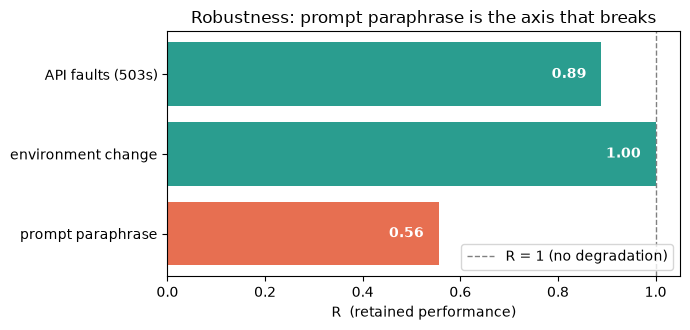

In [7]:
# Example 6: robustness = performance RETAINED under perturbation.
# R = min(Acc_perturbed / Acc_baseline, 1). Accuracy is pass^1 -- the fraction of tasks
# solved. We hardcode which of 10 tasks each run solves (1 = solved), so you can read the
# source data and trace it to R. Faults and JSON reordering barely dent accuracy;
# paraphrasing the user's request is the axis that breaks.

import matplotlib.pyplot as plt


# ===================== the metric =====================
def accuracy(solved):
    """pass^1: the fraction of tasks solved (1 = solved, 0 = failed)."""
    return sum(solved) / len(solved)


def robustness(acc_perturbed, acc_baseline):
    """R: performance retained vs baseline, capped at 1 (never rewards a lucky gain)."""
    return min(acc_perturbed / acc_baseline, 1.0)


# ===================== source data (hardcoded) =====================
# 10 tasks, scored 1 = solved / 0 = failed. Same tasks throughout; only the wording or
# the environment changes between rows. Read each row and trace it to the table below.
baseline   = [1, 1, 1, 1, 1, 1, 1, 1, 1, 0]   # original wording       -> 9/10 solved
api_faults = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]   # inject 503s (p=0.2)    -> 8/10, recovers
env_change = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]   # reorder JSON / rename  -> 10/10, borderline task flips (noise)
paraphrase = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]   # 5 reworded requests    -> 5/10, wording breaks it

perturbations = {
    "API faults (503s)":  api_faults,
    "environment change": env_change,
    "prompt paraphrase":  paraphrase,
}


# ===================== report (auxiliary) =====================
acc_base = accuracy(baseline)
R = {name: robustness(accuracy(solved), acc_base) for name, solved in perturbations.items()}

print(f"baseline accuracy = {acc_base:.0%}\n")
print(f"{'perturbation':20s}  accuracy  raw ratio     R")
print("-" * 51)
for name, solved in perturbations.items():
    acc = accuracy(solved)
    print(f"{name:20s}    {acc:4.0%}     {acc / acc_base:5.2f}      {R[name]:.2f}")

print("\nFaults and reordering stay near baseline (the reorder even flipped the one")
print("borderline task, so its raw ratio tops 1 and the cap clips it to 1.00).")
print("Paraphrasing the request is the axis that breaks R.")


# ===================== visualize (auxiliary) =====================
fig, ax = plt.subplots(figsize=(7, 3.4))
names = list(R)
bars = ax.barh(names, [R[n] for n in names],
               color=["#2a9d8f", "#2a9d8f", "#e76f51"])
ax.axvline(1.0, color="gray", ls="--", lw=1, label="R = 1 (no degradation)")
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("R  (retained performance)")
ax.set_title("Robustness: prompt paraphrase is the axis that breaks")
for bar, n in zip(bars, names):
    ax.text(R[n] - 0.03, bar.get_y() + bar.get_height() / 2, f"{R[n]:.2f}",
            va="center", ha="right", color="white", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 3.4 Predictability: predicting the likelihood of failure

Predictability asks whether the agent knows when it is likely to fail. For each task, it reports confidence $c_i \in [0,1]$, compared with outcome $y_i \in \{0,1\}$. The paper evaluates predictability with three metrics.

**Calibration**

$$
P_{\text{cal}} = 1 - \text{ECE} = 1 - \sum_{b=1}^{B}\frac{n_b}{N}\,\bigl|\bar{y}_b - \bar{c}_b\bigr| \qquad
$$

Where `ECE` means Expected Calibration Error. It groups the $N$ predictions into $B$ confidence bins, and in each bin $b$ compares the average confidence $\bar{c}_b$ with the observed success rate $\bar{y}_b$. Each bin contributes its absolute gap $|\bar{y}_b - \bar{c}_b|$, weighted by its share of tasks $n_b/N$. $P_{\text{cal}} = 1$ means confidence matches reality in every bin.

For example, say 10 tasks fall into two confidence bins of five. The first bin averages confidence 0.75 but its tasks succeed only 60% of the time — a gap of $|0.60 - 0.75| = 0.15$. The second averages confidence 0.25 and its tasks succeed 30% of the time — a gap of $0.05$. Each bin holds half the tasks, so $\text{ECE} = 0.5(0.15) + 0.5(0.05) = 0.10$ and $P_{\text{cal}} = 1 - 0.10 = 0.90$.

**Discrimination**

$$
P_{\mathrm{AUROC}} = \Pr\left(c_i > c_j \mid y_i = 1,\ y_j = 0\right)
$$

Take every pair of one successful task and one failed task; AUROC is the fraction of those pairs in which the success was given the higher confidence (a tie counts as half). 1.0 means confidence always ranks a success above a failure, 0.5 is random, and below 0.5 failures draw higher confidence than successes.

For example, take three successes with confidences $\{0.9, 0.8, 0.6\}$ and three failures with $\{0.7, 0.4, 0.3\}$. Of the $3 \times 3 = 9$ pairs, the success is more confident in 8 — the only miss is the success at 0.6, ranked below the failure at 0.7 — so $P_{\mathrm{AUROC}} = 8/9 \approx 0.89$.

Calibration and discrimination answer different questions. Calibration asks whether confidence values are numerically accurate. Discrimination asks whether confidence correctly ranks easy and risky tasks.

**Brier score**

$$
P_{\mathrm{Brier}} =
1 - \frac{1}{N}\sum_{i=1}^{N}(c_i - y_i)^2
$$

The Brier score measures the squared difference between confidence and outcome for every task. A task the agent calls at 0.9 and then succeeds contributes only $(0.9 - 1)^2 = 0.01$; one it calls at 0.7 and then fails contributes $(0.7 - 0)^2 = 0.49$. Average those two and subtract from 1: $P_{\mathrm{Brier}} = 1 - (0.01 + 0.49)/2 = 0.75$. Because the error is squared, a confident wrong call is punished far more than a confident right one is rewarded, so a single score reflects both calibration and discrimination. The paper reports one minus the usual Brier loss so that, as with the other metrics, higher is better.

--

These three properties can improve independently. Frontier models have become better calibrated, with Claude performing strongest across both benchmarks. But discrimination has not improved: it declines on GAIA, while several models on τ-bench remain near AUROC $0.5$, meaning their confidence scores rank successes and failures little better than chance.

This gap decides whether confidence can support selective automation. A model can be perfectly calibrated in aggregate yet unable to say which specific tasks are risky — the next cell shows two agents that are both perfectly calibrated ($P_{\text{cal}} = 1.00$), where one ranks risk (AUROC 0.82) and the other cannot (0.50). Automatically approving high-confidence cases and routing low-confidence ones to humans requires strong discrimination. Without it, confidence scores may look reasonable on average but cannot support reliable decision thresholds.

base success rate = 50%

agent                                       P_cal  AUROC  P_brier
-----------------------------------------------------------------
discriminating (confidence tracks risk)      1.00   0.82    0.83
blind (one constant confidence)              1.00   0.50    0.75

Both are perfectly calibrated (P_cal = 1.00), yet only the discriminating agent
can RANK risk (AUROC 0.82 vs 0.50). Calibration alone cannot tell them apart --
without discrimination, confidence cannot pick which tasks to route to a human.


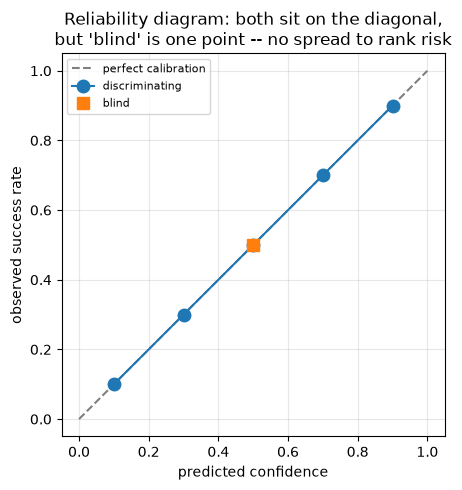

In [8]:
# Example 7: predictability -- calibration can look good while failure DETECTION fails.
# Two agents produce the SAME task outcomes; only their confidence signals differ. We
# hardcode 50 tasks grouped by confidence level (so you can read the source data), then
# run all three metrics on each agent.

import matplotlib.pyplot as plt


# ===================== the metrics =====================
def calibration(conf, outcome, n_bins=10):
    """P_cal = 1 - ECE. Split tasks into confidence bins; in each bin compare the average
    confidence with the actual success rate. ECE is the bin-size-weighted average of those
    gaps, so P_cal = 1 means confidence matches reality in every bin."""
    n, ece = len(conf), 0.0
    for b in range(n_bins):
        lo, hi = b / n_bins, (b + 1) / n_bins
        bin_idx = [i for i in range(n) if lo < conf[i] <= hi]
        if not bin_idx:
            continue
        avg_conf     = sum(conf[i] for i in bin_idx) / len(bin_idx)
        success_rate = sum(outcome[i] for i in bin_idx) / len(bin_idx)
        ece += len(bin_idx) / n * abs(success_rate - avg_conf)
    return 1 - ece


def auroc(conf, outcome):
    """Discrimination. Over every (success, failure) pair, the fraction where the success
    got the HIGHER confidence (ties count as half). 1.0 = always ranks a success above a
    failure; 0.5 = no better than chance."""
    successes = [c for c, y in zip(conf, outcome) if y == 1]
    failures  = [c for c, y in zip(conf, outcome) if y == 0]
    wins = sum((cs > cf) + 0.5 * (cs == cf) for cs in successes for cf in failures)
    return wins / (len(successes) * len(failures))


def brier(conf, outcome):
    """P_brier = 1 - mean squared error between confidence and outcome (higher = better).
    A confident wrong call is punished far more than a confident right one is rewarded."""
    return 1 - sum((c - y) ** 2 for c, y in zip(conf, outcome)) / len(conf)


# ===================== source data (hardcoded) =====================
# 50 tasks, grouped by the confidence the DISCRIMINATING agent assigns them. Each group's
# success rate is built to equal its confidence, so that agent is perfectly calibrated.
# (confidence, outcomes) with 1 = task succeeded, 0 = task failed.
levels = [
    (0.9, [1, 1, 1, 1, 1, 1, 1, 1, 1, 0]),   # 9 of 10 succeed
    (0.7, [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]),   # 7 of 10
    (0.5, [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]),   # 5 of 10
    (0.3, [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),   # 3 of 10
    (0.1, [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]),   # 1 of 10
]

outcomes       = []   # 1 = succeeded, 0 = failed -- SHARED by both agents
discriminating = []   # confidence that tracks each task's risk
for confidence, group in levels:
    for y in group:
        outcomes.append(y)
        discriminating.append(confidence)

base_rate = sum(outcomes) / len(outcomes)      # 0.50
blind     = [base_rate] * len(outcomes)        # one constant confidence for every task


# ===================== report (auxiliary) =====================
agents = {
    "discriminating (confidence tracks risk)": discriminating,
    "blind (one constant confidence)":         blind,
}

print(f"base success rate = {base_rate:.0%}\n")
print(f"{'agent':42s}  P_cal  AUROC  P_brier")
print("-" * 65)
for name, conf in agents.items():
    print(f"{name:42s}   {calibration(conf, outcomes):.2f}   {auroc(conf, outcomes):.2f}    {brier(conf, outcomes):.2f}")

print("\nBoth are perfectly calibrated (P_cal = 1.00), yet only the discriminating agent")
print("can RANK risk (AUROC 0.82 vs 0.50). Calibration alone cannot tell them apart --")
print("without discrimination, confidence cannot pick which tasks to route to a human.")


# ===================== visualize (auxiliary) =====================
def reliability_points(conf, outcome, n_bins=10):
    """One (avg confidence, success rate) point per non-empty confidence bin."""
    xs, ys = [], []
    for b in range(n_bins):
        lo, hi = b / n_bins, (b + 1) / n_bins
        bin_idx = [i for i in range(len(conf)) if lo < conf[i] <= hi]
        if bin_idx:
            xs.append(sum(conf[i] for i in bin_idx) / len(bin_idx))
            ys.append(sum(outcome[i] for i in bin_idx) / len(bin_idx))
    return xs, ys


fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
for (name, conf), style in zip(agents.items(), ["o-", "s"]):
    xs, ys = reliability_points(conf, outcomes)
    ax.plot(xs, ys, style, markersize=9, label=name.split(" (")[0])
ax.set_xlabel("predicted confidence")
ax.set_ylabel("observed success rate")
ax.set_title("Reliability diagram: both sit on the diagonal,\nbut 'blind' is one point -- no spread to rank risk")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 3.5 Safety: reported separately, deliberately

Safety asks how bad things get when a failure happens. It has two parts: how often violations occur, and how severe they are.

- **Compliance** $S_{\text{comp}}$ — the fraction of runs with no violation (a skipped identity check, an unauthorized action). So $\Pr(\text{violation}) = 1 - S_{\text{comp}}$ is how *often* things go wrong.
- **Harm severity** — each violation is scored low (0.25), medium (0.5), or high (1.0), and $\mathbb{E}[\text{severity} \mid \text{violation}]$ is the average of those scores over the runs that did violate: how *badly* things go wrong. The reported form is $S_{\text{harm}} = 1 - \mathbb{E}[\text{severity} \mid \text{violation}]$, so a higher $S_{\text{harm}}$ means milder harm.

The two combine through the classical risk model of Kaplan and Garrick (1981):

$$
R_{\text{saf}} = 1 - \Pr(\text{violation})\cdot\mathbb{E}[\text{severity} \mid \text{violation}] = 1 - (1 - S_{\text{comp}})(1 - S_{\text{harm}})
$$

Risk is *probability × consequence*: multiply how often a violation happens by how bad it is on average, and that product is the expected harm per run; $R_{\text{saf}}$ is 1 minus it. The two forms are the same, since $1 - S_{\text{harm}} = \mathbb{E}[\text{severity} \mid \text{violation}]$.

For example, compare two agents over 100 runs:

| agent | violations | severity | $S_{\text{comp}}$ | $\Pr(\text{viol})$ | $\mathbb{E}[\text{sev}\mid\text{viol}]$ | $R_{\text{saf}}$ |
|---|---|---|---|---|---|---|
| frequent-minor | 10 of 100 | low (0.25) | 0.90 | 0.10 | 0.25 | $1 - 0.10 \times 0.25 = 0.975$ |
| rare-catastrophic | 1 of 100 | high (1.0) | 0.99 | 0.01 | 1.00 | $1 - 0.01 \times 1.00 = 0.990$ |

The rare-catastrophic agent scores *higher* — 0.990 against 0.975 — even though one run in a hundred is catastrophic. A single expected-harm number rewards rarity and cannot see the tail.

That is why safety is excluded from the aggregate reliability score: tail events dominate it. An agent that is safe in 99% of runs but catastrophic in 1% should not earn a good score through averaging.

Aviation follows the same logic, targeting fewer than one catastrophic failure per $10^9$ flight hours rather than a good mean outcome. In τ-bench, the most common violation is financial inaccuracy, including incorrect charges and refunds.

In [9]:
# Example 8: safety = the risk a failure carries, combining HOW OFTEN violations happen
#   with HOW BAD they are:  R_saf = 1 - Pr(violation) * E[severity | violation]
#                                 = 1 - (1 - S_comp) * (1 - S_harm).
# Each run logs None (compliant) or a severity label. We hardcode two agents with opposite
# risk shapes so you can read the runs and trace them to the scores.


# ===================== the metric =====================
SEVERITY = {"low": 0.25, "medium": 0.5, "high": 1.0}   # how bad a single violation is


def safety(runs):
    """runs: each item is None (compliant) or a severity label ('low'/'medium'/'high').
    Returns (S_comp, E[sev|viol], S_harm, R_saf)."""
    n = len(runs)
    violations = [SEVERITY[s] for s in runs if s is not None]
    s_comp = 1 - len(violations) / n                                  # runs with no violation
    e_sev  = sum(violations) / len(violations) if violations else 0.0  # E[severity | violation]
    s_harm = 1 - e_sev                                               # higher = milder harm
    r_saf  = 1 - (1 - s_comp) * e_sev                                # 1 - Pr(viol) * E[sev|viol]
    return s_comp, e_sev, s_harm, r_saf


# ===================== source data (hardcoded) =====================
# 100 runs each. None = compliant run; a label = a violation of that severity.
frequent_minor    = ["low"] * 10 + [None] * 90     # 10 of 100 runs violate, all minor
rare_catastrophic = ["high"] + [None] * 99         #  1 of 100 runs violates, but catastrophic


# ===================== report (auxiliary) =====================
print(f"{'agent':20s}  S_comp  E[sev|viol]  S_harm  R_saf")
print("-" * 58)
for name, runs in [("frequent-minor", frequent_minor),
                   ("rare-catastrophic", rare_catastrophic)]:
    s_comp, e_sev, s_harm, r_saf = safety(runs)
    print(f"{name:20s}  {s_comp:5.1%}     {e_sev:.2f}       {s_harm:.2f}   {r_saf:.3f}")

print("\nThe rare-catastrophic agent scores the HIGHER R_saf (0.990 vs 0.975) -- yet a 1%")
print("catastrophic tail is unacceptable. That is why safety is reported separately, and")
print("why aviation targets a ~1e-9 tail probability, not a good average outcome.")

agent                 S_comp  E[sev|viol]  S_harm  R_saf
----------------------------------------------------------
frequent-minor        90.0%     0.25       0.75   0.975
rare-catastrophic     99.0%     1.00       0.00   0.990

The rare-catastrophic agent scores the HIGHER R_saf (0.990 vs 0.975) -- yet a 1%
catastrophic tail is unacceptable. That is why safety is reported separately, and
why aviation targets a ~1e-9 tail probability, not a good average outcome.


### 3.6 Reinterpreting the four opening incidents

The reliability dimensions make the incidents easier to diagnose.

- **Replit** — high harm severity plus weak prompt robustness. The action was irreversible, and "do not touch the database" did not survive rephrasing.
- **Air Canada** — a policy-compliance failure. The agent invented a rule the policy document did not contain, exactly the failure the τ-bench policy ablation is built to expose.
- **Operator** — a compliance failure, visible in the action sequence: it spent $31.43 without the mandated confirmation.
- **NYC business chatbot** — outcome inconsistency and poor calibration. Ten runs, ten different wrong answers, none flagged as low-confidence.

A common objection is that more capable models will become reliable automatically. That holds only at perfect accuracy. Below that limit, two agents with equal success rates can still differ sharply in consistency, robustness, predictability, and safety. Over eighteen months, capability improved faster than reliability. Scaling alone did not close the gap.



agent                                 Consi  Robus  Predi  Safet
------------------------------------------------------------------
frontier (capable, less reliable)      0.45   0.97   0.50   0.94
reliability-tuned                      1.00   0.97   0.82   0.99


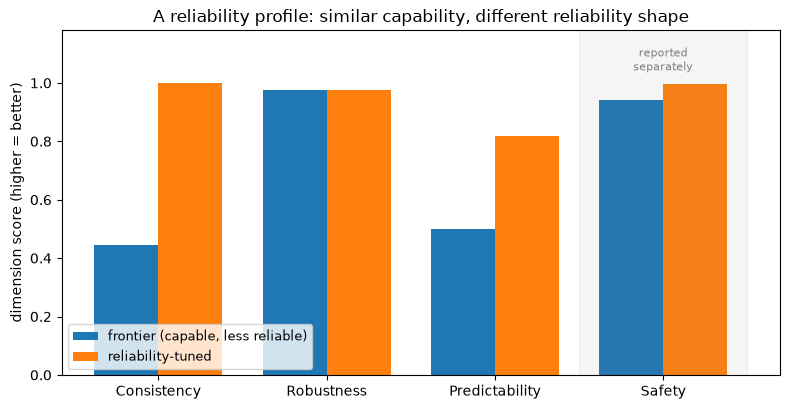


An aggregate reliability score combines the non-safety dimensions (how to weight them
is an engineering choice); Safety is reported separately so a rare catastrophic tail
cannot be averaged into a passing score.


In [10]:
# Example 9: the reliability PROFILE -- report the four dimensions separately, not as one average.
# Two illustrative synthetic agents with similar capability but different reliability shapes.
# (Reuses c_out, auroc, and safety defined in the examples above.)

import random
import matplotlib.pyplot as plt

rng = random.Random(7)


def profile(consistent, robust, discriminating, safe):
    """Build one agent's four dimension scores from small synthetic samples."""
    # Consistency: stable vs scattered failures (both ~85% accurate)
    runs = ([[1] * 5 if t >= 30 else [0] * 5 for t in range(200)] if consistent
            else [[int(rng.random() < 0.85) for _ in range(5)] for _ in range(200)])
    C = c_out(runs)
    # Robustness: accuracy retained under paraphrase, relative to an 0.80 baseline
    R = min((0.78 if robust else 0.52) / 0.80, 1.0)
    # Predictability: confidence that tracks task risk, or a flat constant
    p = [rng.random() for _ in range(500)]
    y = [int(rng.random() < pi) for pi in p]
    conf = ([min(1, max(0, pi + rng.uniform(-0.1, 0.1))) for pi in p] if discriminating
            else [sum(y) / len(y)] * len(p))
    P = auroc(conf, y)
    # Safety: rare-minor vs occasional-high violations
    S = safety((["low"] * 20 + [None] * 980) if safe else (["high"] * 60 + [None] * 940))[3]
    return {"Consistency": C, "Robustness": R, "Predictability": P, "Safety": S}


profiles = {
    "frontier (capable, less reliable)": profile(False, True, False, False),
    "reliability-tuned":                 profile(True,  True, True,  True),
}

dims = ["Consistency", "Robustness", "Predictability", "Safety"]
print(f"{'agent':36s}  " + "  ".join(f"{d[:5]:>5s}" for d in dims))
print("-" * 66)
for name, pr in profiles.items():
    print(f"{name:36s}  " + "  ".join(f"{pr[d]:5.2f}" for d in dims))

x = range(len(dims))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (name, pr) in enumerate(profiles.items()):
    ax.bar([xi + (i - 0.5) * w for xi in x], [pr[d] for d in dims], w, label=name)
ax.axvspan(2.5, 3.5, color="gray", alpha=0.08)          # Safety: reported separately
ax.text(3, 1.03, "reported\nseparately", ha="center", va="bottom", fontsize=8, color="gray")
ax.set_xticks(list(x))
ax.set_xticklabels(dims)
ax.set_ylim(0, 1.18)
ax.set_ylabel("dimension score (higher = better)")
ax.set_title("A reliability profile: similar capability, different reliability shape")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

print("\nAn aggregate reliability score combines the non-safety dimensions (how to weight them")
print("is an engineering choice); Safety is reported separately so a rare catastrophic tail")
print("cannot be averaged into a passing score.")

## 4. Practical use: Integrating reliability into the agent development lifecycle

Metrics only matter if they change how we build. The agent development lifecycle (ADLC) is the agent-specific counterpart to the familiar SDLC, and it runs in six steps.

1. **Define the operating envelope.** Specify supported intents, languages, workflows, tools, and failure modes. Reliability is always relative to this envelope.
2. **Build a representative evaluation environment.** Use real APIs, policy documents, LLM-simulated users, and goal-state grading, following the τ-bench structure. One task should map to one outcome.
3. **Run repeated and perturbed tests.** A single success is weak evidence. Run each task multiple times, report pass^k rather than pass^1 alone, and test paraphrases, tool failures, and environment changes. Agent CI requires repeated runs, not one green execution.
4. **Create a context-specific reliability profile.** Report the four dimensions separately and weight them by application. Consistency is critical for code generation in CI/CD but less important for brainstorming, where variation may help. Weighting is an engineering choice.
5. **Enforce release gates.** Require minimum thresholds before pilot-to-production promotion. Human-reviewed systems can tolerate more uncertainty than autonomous ones.

   Evaluation is necessary but insufficient. Replit was both a reliability failure and a containment failure. Metrics could have flagged the risk; stronger permissions could have blocked the destructive action. Evaluation decides when to trust the agent. Containment limits the cost when that decision is wrong.
6. **Turn production failures into regression tests.** Add every incident to the evaluation suite and map it to a reliability dimension. Rerun the suite regularly because APIs, schemas, policies, and user behavior change. Qualification in January does not guarantee qualification in June.



## 5. Open problems

Three problems remain open.

1. Fixed test sets decay as models memorize them, so benchmarks need to become generative and parameterized — sampling fresh environments rather than replaying a fixed set.
2. Multi-agent reliability lacks strong metrics and attribution methods. Errors propagate across agent boundaries, making the source of failure hard to identify.
3. Safety evaluation depends heavily on LLM judges. Those judges share the same weaknesses— inconsistency, prompt sensitivity, and calibration errors—as the systems they grade.

## 6. Conclusion

The key question is no longer only, “How often does the agent succeed?” It is, “How consistently, robustly, predictably, and safely does it behave?”

τ-bench made these questions measurable. The reliability framework separated them into dimensions. The ADLC connects them to testing, release, monitoring, and containment.

The Replit agent could write code but could not be trusted. Closing that gap requires an engineering discipline for measuring behavior, limiting damage, and improving reliability—not another model release.
